### Time Series Forecasting with Prophet

In [52]:
import numpy as np
import pandas as pd
import math
import itertools 
from sklearn.metrics import mean_squared_error, mean_absolute_error

#matplotlib libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
import seaborn as sns
import matplotlib.dates as mdates

#date libraries
from datetime import datetime, timedelta, date

#prophet library
from prophet import Prophet

In [53]:
# Read in the csv
df = pd.read_csv("Resources/zillow_cleaned.csv", index_col=0)

In [54]:
# Show the date range of our data
min(df['Date']), max(df['Date'])

('2000-01-31', '2025-02-28')

In [55]:
# Preview the DataFrame
df.head()

,Neighborhood,Date,Price,Year,Month,TimeIndex,Month_sin,Month_cos
0,Gateway - Green Valley Ranch,2000-01-31,159100.744442,2000,1,1,0.5,0.866025
1,Montbello,2000-01-31,126411.509704,2000,1,1,0.5,0.866025
3,Hampden,2000-01-31,166128.053070,2000,1,1,0.5,0.866025
4,Five Points,2000-01-31,188674.759005,2000,1,1,0.5,0.866025
5,Westwood,2000-01-31,91172.123773,2000,1,1,0.5,0.866025


In [56]:
agg_df = df.groupby(['Date','Neighborhood']).agg({'Price':'sum'}).reset_index().sort_values(['Neighborhood','Date'])
agg_df.head()

,Date,Neighborhood,Price
0,2000-01-31,Athmar Park,128427.716292
70,2000-02-29,Athmar Park,129084.048747
140,2000-03-31,Athmar Park,129873.860507
210,2000-04-30,Athmar Park,131756.985161
280,2000-05-31,Athmar Park,133968.822314


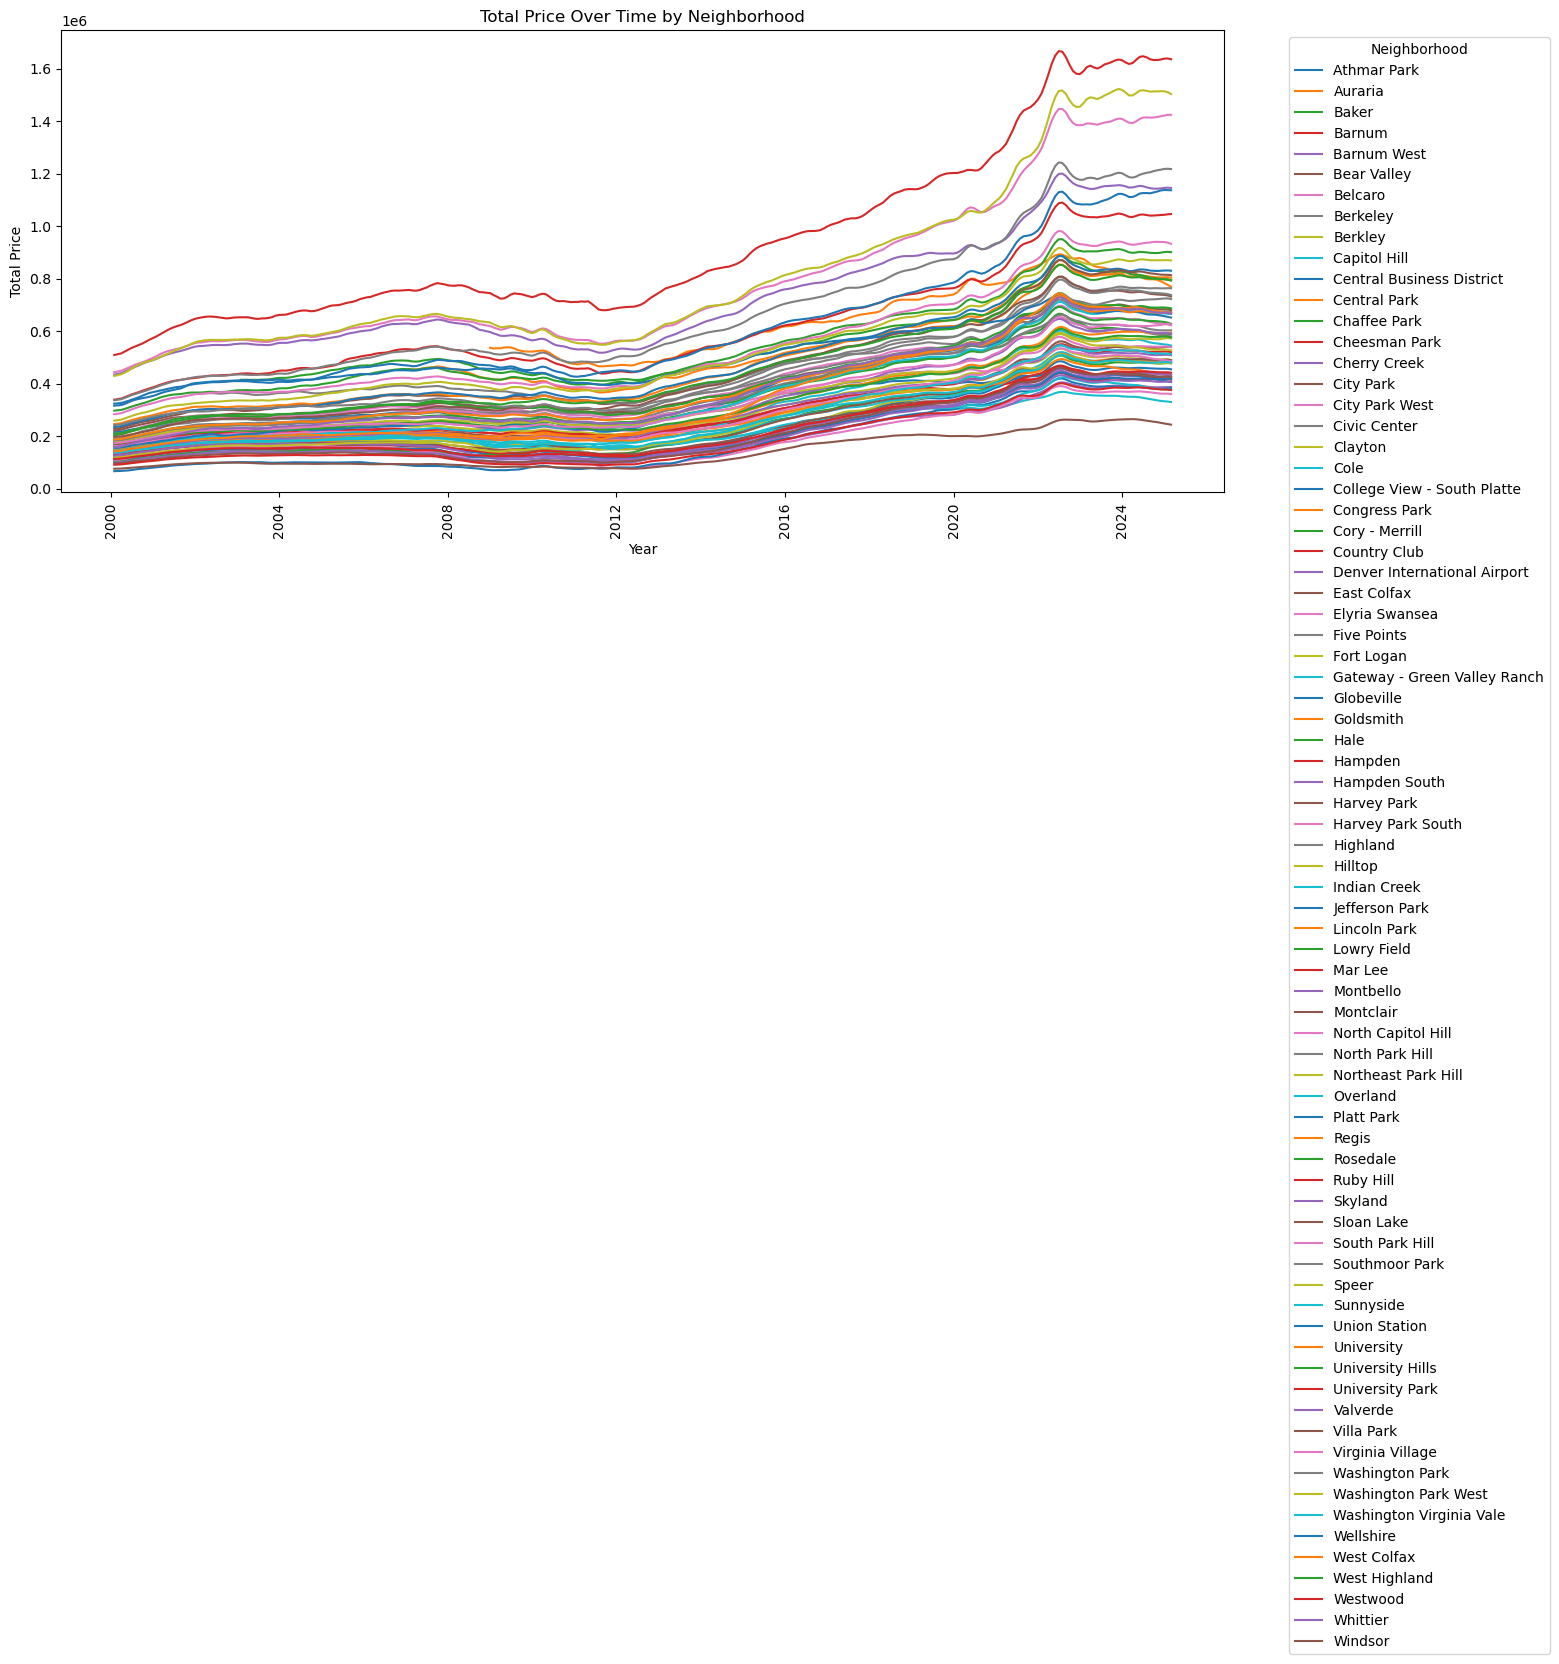

In [57]:
# Preview data in a plot
# Make sure Date column is datetime
agg_df['Date'] = pd.to_datetime(agg_df['Date'], errors='coerce')

# Pivot so each neighborhood is its own column
pivot_df = agg_df.pivot(index='Date', columns='Neighborhood', values='Price')

# Plot
plt.figure(figsize=(15, 6))
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], label=column)

# Format the x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Total Price')
plt.title('Total Price Over Time by Neighborhood')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='best') 
plt.show()

In [58]:
# Select a start date for the forecast
forecast_start_dt = date(2024,1,1) 
forecast_start_date = (forecast_start_dt).strftime("%Y-%m-%d") 
print(forecast_start_date)

forecast_periods = 120  # number of months to forecast

2024-01-01


In [59]:
df_copy = df.copy()

# # Rename Date and Price columns to be in Prophet format
df_copy = df_copy.rename(columns={'Date': 'ds', 'Price': 'y'})
df_copy[['y']] = df_copy[['y']].apply(pd.to_numeric)
df_copy['ds'] = pd.to_datetime(df_copy['ds'])

In [60]:
# Fit and train model and predict by neighborhood

# Dictionary to hold forecasts for all neighborhoods
all_forecasts = []

# Get list of unique neighborhoods
neighborhoods = df_copy['Neighborhood'].unique()

for neighborhood in neighborhoods:
    # Filter data for the neighborhood and training set only
    neighborhood_data = df_copy[df_copy['Neighborhood'] == neighborhood]
    train_set = neighborhood_data[neighborhood_data['ds'] < forecast_start_date]

    # Initialize and fit Prophet model on training data
    model = Prophet()
    model.fit(train_set[['ds', 'y']])

    # Create future dataframe (extending forecast_periods months after last date)
    future = model.make_future_dataframe(periods=forecast_periods, freq='ME')

    # Predict future values
    forecast = model.predict(future)

    # Filter forecast to only dates >= forecast_start_date
    predicted = forecast[forecast['ds'] >= forecast_start_date][['ds', 'yhat']]

    # Add neighborhood column for identification
    predicted['Neighborhood'] = neighborhood

    # Append to list
    all_forecasts.append(predicted)

# Combine all neighborhood forecasts into a single DataFrame
predicted_df = pd.concat(all_forecasts).reset_index(drop=True)

21:11:31 - cmdstanpy - INFO - Chain [1] start processing
21:11:31 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing
21:11:32 - cmdstanpy - INFO - Chain [1] start processing
21:11:33 - cmdstanpy - INFO - Chain [1] done processing
21:11:33 - cmdstanpy - INFO - Chain [1] start processing
21:11:33 - cmdstanpy - INFO - Chain [1]

In [61]:
# Preview the predicted data
predicted_df

,ds,yhat,Neighborhood
0,2024-01-31,523646.022278,Gateway - Green Valley Ranch
1,2024-02-29,526258.956820,Gateway - Green Valley Ranch
2,2024-03-31,530649.466277,Gateway - Green Valley Ranch
3,2024-04-30,534968.144826,Gateway - Green Valley Ranch
4,2024-05-31,538681.888496,Gateway - Green Valley Ranch
...,...,...,...
9115,2033-08-31,380519.902054,Berkley
9116,2033-09-30,378384.366019,Berkley
9117,2033-10-31,376275.186007,Berkley
9118,2033-11-30,374759.164271,Berkley


In [62]:
# Prepare the true data
df_true = df[['Date', 'Price', 'Neighborhood']].copy()
df_true.columns = ['ds', 'ytrue', 'Neighborhood']

# Ensure date columns are datetime
df_true['ds'] = pd.to_datetime(df_true['ds'], errors='coerce')
predicted_df['ds'] = pd.to_datetime(predicted_df['ds'], errors='coerce')

# Merge on both 'ds' and 'Neighborhood'
merged_df = predicted_df.merge(df_true, on=['ds', 'Neighborhood'], how='inner')


In [63]:
# Preview the predicted values compared to the true values 
merged_df

,ds,yhat,Neighborhood,ytrue
0,2024-01-31,523646.022278,Gateway - Green Valley Ranch,491007.161995
1,2024-02-29,526258.956820,Gateway - Green Valley Ranch,491035.364888
2,2024-03-31,530649.466277,Gateway - Green Valley Ranch,491392.950975
3,2024-04-30,534968.144826,Gateway - Green Valley Ranch,491882.612105
4,2024-05-31,538681.888496,Gateway - Green Valley Ranch,491760.579762
...,...,...,...,...
1059,2024-10-31,473084.310064,Berkley,487396.354496
1060,2024-11-30,471204.418674,Berkley,486050.614707
1061,2024-12-31,468702.941247,Berkley,485837.081645
1062,2025-01-31,467728.163599,Berkley,484818.234776


In [64]:
# Create Mean Absolute Percentage Error (MAPE) function
# Compares the true value to the predicted value
def mape(actual, pred): 
    '''
    Mean Absolute Percentage Error (MAPE) Function
    
    input: list/series for actual values and predicted values
    output: mape value 
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

In [65]:
# Group by neighborhood and calculate MAPE
mape_by_neighborhood = (
    merged_df.groupby('Neighborhood')
    .apply(lambda group: mape(group['ytrue'], group['yhat']))
    .reset_index(name='MAPE') 
) 

# Display per-neighborhood MAPE
print(mape_by_neighborhood)

     Neighborhood       MAPE
0     Athmar Park  10.856840
1         Auraria  12.132632
2           Baker  13.229226
3          Barnum  10.794043
4     Barnum West  10.576588
..            ...        ...
71    West Colfax  12.636629
72  West Highland  10.520783
73       Westwood  10.609932
74       Whittier  11.166899
75        Windsor   5.905326

[76 rows x 2 columns]


/var/folders/lg/wkj6jfhs0ws66h3j7jl58y640000gn/T/ipykernel_51460/227162896.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: mape(group['ytrue'], group['yhat']))


In [66]:
# Get metrics for accuracy of the predictions vs. the actual data
# RMSE
rmse = np.sqrt(mean_squared_error(merged_df['ytrue'], merged_df['yhat']))

# MAE
mae = mean_absolute_error(merged_df['ytrue'], merged_df['yhat'])

# MAPE
overall_mape = mape(merged_df['ytrue'], merged_df['yhat'])

# Display results
print(f"Overall RMSE: ${rmse:,.2f}")
print(f"Overall MAE: ${mae:,.2f}")
print(f"Overall MAPE: {overall_mape:.2f}%")

Overall RMSE: $71,127.43
Overall MAE: $64,636.74
Overall MAPE: 10.24%


**Root Mean Squared Error (RMSE)** measures the average prediction error in dollars but penalizes larger errors more heavily.

**Mean Absolute Error (MAE)** calculates the average absolute error in dollars, treating all errors equally.

**Mean Absolute Percentage Error (MAPE)** expresses the average error as a percentage of the actual values, making it useful for comparing performance across different price ranges.

In [67]:
# Get forecast for all neighborhoods
# Dictionary to store individual forecasts
results = {}

# List to collect all forecast DataFrames
forecast_list = []

for neigh in df['Neighborhood'].unique():
    df_n = df[df['Neighborhood'] == neigh][['Date', 'Price']].rename(columns={'Date':'ds', 'Price':'y'})
    df_n['ds'] = pd.to_datetime(df_n['ds'])
    
    model = Prophet()
    model.fit(df_n)
    
    # Forecast 10 years out
    future = model.make_future_dataframe(periods=120, freq='ME')

    forecast = model.predict(future)

    # Add neighborhood column
    forecast['Neighborhood'] = neigh  
    
    results[neigh] = forecast
    forecast_list.append(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'Neighborhood']])

# Combine all into one DataFrame
all_forecasts_df = pd.concat(forecast_list, ignore_index=True)

# Preview the combined DataFrame
all_forecasts_df

21:11:42 - cmdstanpy - INFO - Chain [1] start processing
21:11:42 - cmdstanpy - INFO - Chain [1] done processing
21:11:42 - cmdstanpy - INFO - Chain [1] start processing
21:11:42 - cmdstanpy - INFO - Chain [1] done processing
21:11:42 - cmdstanpy - INFO - Chain [1] start processing
21:11:42 - cmdstanpy - INFO - Chain [1] done processing
21:11:42 - cmdstanpy - INFO - Chain [1] start processing
21:11:43 - cmdstanpy - INFO - Chain [1] done processing
21:11:43 - cmdstanpy - INFO - Chain [1] start processing
21:11:43 - cmdstanpy - INFO - Chain [1] done processing
21:11:43 - cmdstanpy - INFO - Chain [1] start processing
21:11:43 - cmdstanpy - INFO - Chain [1] done processing
21:11:43 - cmdstanpy - INFO - Chain [1] start processing
21:11:43 - cmdstanpy - INFO - Chain [1] done processing
21:11:43 - cmdstanpy - INFO - Chain [1] start processing
21:11:43 - cmdstanpy - INFO - Chain [1] done processing
21:11:43 - cmdstanpy - INFO - Chain [1] start processing
21:11:43 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,Neighborhood
0,2000-01-31,169469.384205,149540.267110,1.881872e+05,Gateway - Green Valley Ranch
1,2000-02-29,170911.547714,151877.726981,1.887992e+05,Gateway - Green Valley Ranch
2,2000-03-31,174933.485362,156252.542753,1.943017e+05,Gateway - Green Valley Ranch
3,2000-04-30,176716.620634,156956.145719,1.955783e+05,Gateway - Green Valley Ranch
4,2000-05-31,178164.971312,159584.424103,1.971763e+05,Gateway - Green Valley Ranch
...,...,...,...,...,...
31517,2034-10-31,515097.636169,56028.560866,9.858558e+05,Berkley
31518,2034-11-30,514974.410818,49072.973823,9.926752e+05,Berkley
31519,2034-12-31,514993.083853,39589.807632,1.001262e+06,Berkley
31520,2035-01-31,515421.013438,35076.450828,1.008877e+06,Berkley


In [74]:
# Get average yearly prices and export into a csv file
# Extract Year and Quarter
all_forecasts_df["Year"] = all_forecasts_df["ds"].dt.year
all_forecasts_df["Prophet Predicted Home Value"] = all_forecasts_df["yhat"]

# Group by year and get average value
yearly_avg = all_forecasts_df.groupby(
    ["Year", "Neighborhood"]
)["Prophet Predicted Home Value"].mean().round(2).reset_index()

yearly_avg_forecast = yearly_avg.copy()
# Filter for years 2024–2036
yearly_avg_forecast = yearly_avg_forecast[(yearly_avg_forecast["Year"] >= 2024) & (yearly_avg_forecast["Year"] <= 2035)]

# Calculate YoY Growth Rate
yearly_avg_forecast['YoY_Growth'] = yearly_avg_forecast.groupby('Neighborhood')['Prophet Predicted Home Value'].pct_change() * 100


# Export to CSV
yearly_avg_forecast.to_csv("Resources/prophet_forecast.csv", index=False)